# Baseline Detection — Clean Baseline Demand Probability (no promotion signal)

Predicts what demand *would have been without promotion* at **product × store × week** granularity with one two-stage hurdle model trained only on non-promoted weeks:

- **Stage 1 (binary):** `P(demand > 0)` — LightGBM classifier.
- **Stage 2 (Poisson):** `E[qty | qty > 0]` — LightGBM Poisson regression on positive weeks.
- **Combined:** `pred = P(positive) × E[qty | positive]`.

**Feature set (this run):** all **54 engineered features** stay in the panel, and the **top 30 are selected by LightGBM gain importance** from a stage-1 selector trained on the full pool (train weeks only). The old 51-feature model and its comparison are removed.

**Training (this run):** time-based split — the two-stage model trains on the **train** weeks (1–79, non-promoted) with **no early stopping** (all `N_ESTIMATORS` trees), and metrics are reported on the **train** split plus a held-out **test** split (weeks 80–101, ~1/5 of the data, non-promoted weeks only). A final per-product plot shows how well the baseline predicts **promoted** weeks for each product.

**Sample selection:** products with fewer than 10 weeks of data (in the training window) are filtered out. **Leakage safety:** every feature uses only information available before the predicted week (lags/rollings end at `t-1`, encoders fit on the training window, selection on training weeks only).

**Outputs** (`outputs/baseline_engine/`): `panel.parquet`, `model_stage1.pkl`, `model_stage2.pkl`, `model.pkl`, `train_predictions.parquet`, `test_predictions.parquet` (real held-out test weeks 80–101, non-promoted rows), `feature_list.json`, `metrics.json` (train + test metrics + detection), `smoothing_config.json`, `config.json`, `residual_buckets.parquet`, `figures/shap_importance.png`, `figures/promo_baseline_vs_actual.png`, `figures/baseline_vs_actual_product_*.png` (one per selected product).

In [5]:
# Imports + minimal config
from __future__ import annotations

import json
import time
from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import LabelEncoder

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw" / "transaction_data.csv").exists():
    ROOT = next(p for p in ROOT.parents if (p / "data" / "raw" / "transaction_data.csv").exists())
RAW = ROOT / "data" / "raw"
OUT = ROOT / "outputs" / "baseline_engine"
(OUT / "figures").mkdir(parents=True, exist_ok=True)

# Settings
MIN_PRODUCT_WEEKS = 0      # min distinct sales weeks (in the training window) for a product to enter the panel
MIN_WEEKS = 15               # min sales weeks for a product-store pair to enter the panel (training window only)
FIRST_WEEK, LAST_WEEK = 1, 102
TRAIN_END = 79   # train 1-79 (non-promoted weeks only)
TEST_START = 80  # held-out test weeks 80-101 (~1/5 of the 101 weeks)
N_ESTIMATORS, LR, NUM_LEAVES = 500, 0.01, 31
SEED = 42

## 1. Load data

Two raw tables are used:
- `transaction_data.csv` — basket-line transactions (product, store, week, quantity, sales value, discount, **household_key**)
- `product.csv` — product attributes (department, commodity, sub-commodity, brand, manufacturer, size)

A week is **promoted** when any of its transactions carries a retail discount (`RETAIL_DISC < 0`); promoted weeks are never used for training.

In [6]:
# 1. Load raw tables
TX_COLS = ["household_key", "PRODUCT_ID", "QUANTITY", "SALES_VALUE", "STORE_ID", "RETAIL_DISC", "WEEK_NO"]
tx = pd.read_csv(RAW / "transaction_data.csv", usecols=TX_COLS)
product = pd.read_csv(RAW / "product.csv")
print(f"transactions: {len(tx):,} | weeks {tx.WEEK_NO.min()}-{tx.WEEK_NO.max()} | "
      f"stores {tx.STORE_ID.nunique():,} | products {tx.PRODUCT_ID.nunique():,} | "
      f"households {tx['household_key'].nunique():,}")

transactions: 2,595,732 | weeks 1-102 | stores 582 | products 92,339 | households 2,500


## 2. Continuous weekly panel

Transactions are aggregated to product × store × week, then reindexed onto a continuous week grid (missing weeks are zero-filled).

**Sample selection is training-window-only:** products with fewer than `MIN_PRODUCT_WEEKS = 10` sales weeks are filtered out (no volume/record-count ranking), and product-store pairs need at least `MIN_WEEKS` sales weeks — all computed **only on weeks ≤ `TRAIN_END`**, so sales from later weeks never influence which units enter the panel.

In [7]:
# 2. Aggregate transactions to product x store x week (continuous grid, zero-filled)
WEEKS = np.arange(FIRST_WEEK, LAST_WEEK, dtype="int16")

def build_panel(tx, select_end):
    tx = tx.copy()
    tx["promo_week"] = (tx["RETAIL_DISC"] < 0).astype("int8")
    weekly = tx.groupby(["PRODUCT_ID", "STORE_ID", "WEEK_NO"], as_index=False).agg(
        qty=("QUANTITY", "sum"), sales_value=("SALES_VALUE", "sum"), promo_week=("promo_week", "max"))
    # unique households per product-week (for household demand features)
    hh_weekly = (tx[tx["QUANTITY"] > 0].groupby(["PRODUCT_ID", "WEEK_NO"])["household_key"]
                 .nunique().rename("n_households").reset_index())
    # product selection: keep products with >= MIN_PRODUCT_WEEKS sales weeks in the TRAINING window only
    sel = weekly[weekly["WEEK_NO"] <= select_end]
    p_weeks = sel.groupby("PRODUCT_ID")["WEEK_NO"].nunique()
    keep_products = p_weeks[p_weeks >= MIN_PRODUCT_WEEKS].index
    weekly = weekly[weekly["PRODUCT_ID"].isin(keep_products)]
    # pair selection: product-store pairs with >= MIN_WEEKS sales weeks in the TRAINING window only
    pair_weeks = weekly[weekly["WEEK_NO"] <= select_end].groupby(["PRODUCT_ID", "STORE_ID"])["WEEK_NO"].nunique()
    pairs = pair_weeks[pair_weeks >= MIN_WEEKS].index
    pair_df = pd.DataFrame({"PRODUCT_ID": pairs.get_level_values(0).to_numpy(),
                            "STORE_ID": pairs.get_level_values(1).to_numpy()})
    weekly = weekly.merge(pair_df, on=["PRODUCT_ID", "STORE_ID"], how="inner")
    # reindex selected pairs onto the full continuous week grid
    grid = pd.MultiIndex.from_arrays([
        np.repeat(pairs.get_level_values(0).to_numpy(), len(WEEKS)),
        np.repeat(pairs.get_level_values(1).to_numpy(), len(WEEKS)),
        np.tile(WEEKS, len(pairs)),
    ], names=["PRODUCT_ID", "STORE_ID", "WEEK_NO"])
    panel = weekly.set_index(["PRODUCT_ID", "STORE_ID", "WEEK_NO"]).reindex(grid, fill_value=0).reset_index()
    panel["promo_week"] = panel["promo_week"].astype("int8")
    # household x product x week purchase events (non-promoted transactions only) -> product-popularity features
    tx_np = tx[tx["promo_week"] == 0]
    hh_events = (tx_np[tx_np["QUANTITY"] > 0]
                 .groupby(["household_key", "PRODUCT_ID", "WEEK_NO"])["QUANTITY"].sum().reset_index())
    hh_events = hh_events[hh_events["PRODUCT_ID"].isin(pairs.get_level_values(0).unique())]
    hh_events = hh_events.sort_values(["household_key", "PRODUCT_ID", "WEEK_NO"]).reset_index(drop=True)
    hh_events["next_week"] = (hh_events.groupby(["household_key", "PRODUCT_ID"])["WEEK_NO"]
                              .shift(-1).fillna(int(WEEKS[-1]) + 1).astype("int16"))
    return panel, weekly, hh_weekly, hh_events

t0 = time.time()
N_HOUSEHOLDS = int(tx["household_key"].nunique())
panel, weekly, hh_weekly, hh_events = build_panel(tx, select_end=TRAIN_END)
del tx
print(f"panel: {len(panel):,} rows | {panel['PRODUCT_ID'].nunique():,} products | "
      f"{panel[['PRODUCT_ID', 'STORE_ID']].drop_duplicates().shape[0]:,} pairs | "
      f"promoted weeks {100 * panel['promo_week'].mean():.1f}% | {time.time() - t0:.0f}s")

panel: 1,127,867 rows | 2,637 products | 11,167 pairs | promoted weeks 13.8% | 12s


## 3. Past-only features (all 54 computed, top 30 used)

All engineered features (54 total: the former 51-feature set plus 3 product-popularity features) are computed below so the **top 30 can be selected over the full pool**. Selection happens in §4 via LightGBM **gain importance** from a stage-1 classifier trained on all 54 features (train weeks only, no early stopping).

No feature contains current-week or future information; every rolling feature applies `shift(1)` **before** aggregation and every encoder is fitted on the training window only.

In [8]:
# 3. Past-only features (old 51 computed, new 22 used)
KEY = ["PRODUCT_ID", "STORE_ID"]
CAT_COLS = ["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "BRAND", "MANUFACTURER"]
PROD_META = ["MANUFACTURER", "DEPARTMENT", "BRAND", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "CURR_SIZE_OF_PRODUCT"]

# Canonical (product, store, week) order — feature functions rely on group order == row order
panel = panel.sort_values(KEY).reset_index(drop=True)

def add_time_features(p):
    # raw week/month remain in the panel for calendar encoding and display, not as model features
    p["week"] = p["WEEK_NO"].astype("int16")
    p["month"] = ((p["WEEK_NO"] - 1) // 4) % 12 + 1
    p["week_sin"] = np.sin(2 * np.pi * p["WEEK_NO"] / 52)
    p["week_cos"] = np.cos(2 * np.pi * p["WEEK_NO"] / 52)
    p["month_sin"] = np.sin(2 * np.pi * p["month"] / 12)
    p["month_cos"] = np.cos(2 * np.pi * p["month"] / 12)

def add_demand_history(p):
    # Promoted weeks masked from demand history; all windows end at t-1.
    p["base_qty"] = np.where(p["promo_week"] == 0, p["qty"], np.nan)
    p["base_qty"] = p.groupby(KEY, sort=False)["base_qty"].ffill().fillna(0.0)
    for lag in (1, 2, 4, 8, 12):
        p[f"qty_lag{lag}"] = p.groupby(KEY, sort=False)["base_qty"].shift(lag).fillna(0.0).to_numpy()
    idx = p.set_index(KEY)
    shifted = idx.groupby(level=[0, 1])["base_qty"].shift(1)      # ends at t-1
    p["rmean2"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(2, min_periods=2).mean().to_numpy())
    p["rmean4"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(4, min_periods=2).mean().to_numpy())
    p["rmean8"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(8, min_periods=3).mean().to_numpy())
    p["rstd4"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(4, min_periods=2).std().to_numpy())
    p["rstd8"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(8, min_periods=3).std().to_numpy())
    p["rmax4"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(4, min_periods=2).max().to_numpy())
    p["rmax8"] = np.nan_to_num(shifted.groupby(level=[0, 1]).rolling(8, min_periods=3).max().to_numpy())
    p["trend8"] = p["rmean4"] - p["rmean8"]

def add_price_promo(p):
    p["price"] = np.where(p["qty"] > 0, p["sales_value"] / p["qty"], np.nan)
    p["price"] = p.groupby(KEY, sort=False)["price"].ffill().fillna(0.0)
    idx = p.set_index(KEY)
    price_prev = idx.groupby(level=[0, 1])["price"].shift(1)        # ends at t-1
    promo_prev = idx.groupby(level=[0, 1])["promo_week"].shift(1)   # ends at t-1
    p["price_lag1"] = np.nan_to_num(price_prev.to_numpy())
    p["price_lag4"] = np.nan_to_num(idx.groupby(level=[0, 1])["price"].shift(4).to_numpy())
    p["price_rmean4"] = np.nan_to_num(price_prev.groupby(level=[0, 1]).rolling(4, min_periods=2).mean().to_numpy())
    p["promo_lag1"] = np.nan_to_num(promo_prev.to_numpy()).astype("int8")
    p["promo_lag2"] = np.nan_to_num(idx.groupby(level=[0, 1])["promo_week"].shift(2).to_numpy()).astype("int8")
    p["promo_share8"] = np.nan_to_num(promo_prev.groupby(level=[0, 1]).rolling(8, min_periods=1).mean().to_numpy())

def add_occurrence_features(p):
    # demand-occurrence features — strictly past-only (derived from base_qty shifted by 1)
    idx = p.set_index(KEY)
    pos_prev = (idx.groupby(level=[0, 1])["base_qty"].shift(1) > 0).astype("int32")  # sold at t-1
    pos_week = p["WEEK_NO"].where(p["base_qty"] > 0)
    last_sale = pos_week.groupby([p["PRODUCT_ID"], p["STORE_ID"]], sort=False).shift(1)
    p["weeks_since_last_sale"] = (p["WEEK_NO"] - last_sale).fillna(999).astype("int32")
    z = (pos_prev == 0).astype("int32")
    cum = z.groupby(level=[0, 1]).cumsum()
    reset = cum.where(z == 0).groupby(level=[0, 1]).ffill()
    p["zero_streak_length"] = (cum - reset.fillna(0)).astype("int32").to_numpy()
    pos_f = pos_prev.astype("float32")
    for w in (4, 8, 12, 26):
        p[f"positive_rate_{w}w"] = pos_f.groupby(level=[0, 1]).rolling(w, min_periods=1).mean().to_numpy()
    p["demand_decay"] = (p["rmean4"] + 1e-3) / (p["rmean8"] + 1e-3)

def add_attributes(p, product):
    p = p.merge(product[["PRODUCT_ID", *PROD_META]], on="PRODUCT_ID", how="left")
    p["size_num"] = p["CURR_SIZE_OF_PRODUCT"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0].astype(float)
    return p

def add_context_features(p, weekly, hh_weekly, product):
    # ---- 1) product-global weekly activity (all stores), continuous week grid ----
    gw = weekly.assign(sold=(weekly["qty"] > 0).astype("int32")).groupby(
        ["PRODUCT_ID", "WEEK_NO"], as_index=False).agg(global_qty=("qty", "sum"), n_sold_stores=("sold", "sum"))
    sel_products = p["PRODUCT_ID"].unique()
    g_grid = pd.MultiIndex.from_product([sel_products, WEEKS], names=["PRODUCT_ID", "WEEK_NO"])
    gw = gw.set_index(["PRODUCT_ID", "WEEK_NO"]).reindex(g_grid, fill_value=0).reset_index()
    gw = gw.sort_values(["PRODUCT_ID", "WEEK_NO"]).reset_index(drop=True)
    g = gw.groupby("PRODUCT_ID", sort=False)
    gw["product_global_qty_lag1"] = g["global_qty"].shift(1).fillna(0.0).to_numpy()
    g_shift = g["global_qty"].shift(1)                                        # ends at t-1
    gw["product_global_qty_rmean4"] = np.nan_to_num(
        g_shift.groupby(gw["PRODUCT_ID"]).rolling(4, min_periods=2).mean().to_numpy())
    gw["product_global_qty_rmean8"] = np.nan_to_num(
        g_shift.groupby(gw["PRODUCT_ID"]).rolling(8, min_periods=3).mean().to_numpy())
    pos8 = (gw["global_qty"] > 0).astype("float32").groupby(gw["PRODUCT_ID"]).shift(1)  # positive at t-1
    gw["product_global_positive_rate8"] = np.nan_to_num(
        pos8.groupby(gw["PRODUCT_ID"]).rolling(8, min_periods=1).mean().to_numpy())
    st_shift = g["n_sold_stores"].shift(1)
    gw["product_active_stores_rmean8"] = np.nan_to_num(
        st_shift.groupby(gw["PRODUCT_ID"]).rolling(8, min_periods=2).mean().to_numpy())
    gw["active_weeks_last_26"] = np.nan_to_num(
        pos8.groupby(gw["PRODUCT_ID"]).rolling(26, min_periods=1).sum().to_numpy())
    gw["sales_decay_ratio"] = (gw["product_global_qty_rmean4"] + 1e-3) / (gw["product_global_qty_rmean8"] + 1e-3)
    p = p.merge(gw[["PRODUCT_ID", "WEEK_NO", "product_global_qty_lag1", "product_global_qty_rmean4",
                    "product_global_qty_rmean8", "product_global_positive_rate8",
                    "product_active_stores_rmean8", "active_weeks_last_26", "sales_decay_ratio"]],
                on=["PRODUCT_ID", "WEEK_NO"], how="left")

    # ---- 2) category (SUB_COMMODITY_DESC x WEEK) activity, continuous week grid ----
    p["SUB_COMMODITY_DESC"] = p["SUB_COMMODITY_DESC"].fillna("UNKNOWN")
    prod_cat = product[["PRODUCT_ID", "SUB_COMMODITY_DESC"]].assign(
        SUB_COMMODITY_DESC=lambda d: d["SUB_COMMODITY_DESC"].fillna("UNKNOWN"))
    cw = weekly.merge(prod_cat, on="PRODUCT_ID", how="left")
    cw["SUB_COMMODITY_DESC"] = cw["SUB_COMMODITY_DESC"].fillna("UNKNOWN")
    cg = cw.groupby(["SUB_COMMODITY_DESC", "WEEK_NO"], as_index=False)["qty"].sum().rename(columns={"qty": "category_qty"})
    cg["cat_pos"] = (cg["category_qty"] > 0).astype("float32")
    n_active = (cw[cw["qty"] > 0].groupby(["SUB_COMMODITY_DESC", "WEEK_NO"])["PRODUCT_ID"]
                .nunique().rename("n_active_products").reset_index())
    cg = cg.merge(n_active, on=["SUB_COMMODITY_DESC", "WEEK_NO"], how="left")
    cats = pd.unique(p["SUB_COMMODITY_DESC"])
    c_grid = pd.MultiIndex.from_product([cats, WEEKS], names=["SUB_COMMODITY_DESC", "WEEK_NO"])
    cg = cg.set_index(["SUB_COMMODITY_DESC", "WEEK_NO"]).reindex(c_grid).reset_index()
    cg["n_active_products"] = cg["n_active_products"].fillna(0)
    cg = cg.sort_values(["SUB_COMMODITY_DESC", "WEEK_NO"]).reset_index(drop=True)
    cc = cg.groupby("SUB_COMMODITY_DESC", sort=False)
    c_shift = cc["category_qty"].shift(1)                                     # ends at t-1
    cg["category_qty_rmean4"] = np.nan_to_num(
        c_shift.groupby(cg["SUB_COMMODITY_DESC"]).rolling(4, min_periods=2).mean().to_numpy())
    cg["category_qty_rmean8"] = np.nan_to_num(
        c_shift.groupby(cg["SUB_COMMODITY_DESC"]).rolling(8, min_periods=3).mean().to_numpy())
    cat_pos8 = cc["cat_pos"].shift(1)
    cg["category_positive_rate8"] = np.nan_to_num(
        cat_pos8.groupby(cg["SUB_COMMODITY_DESC"]).rolling(8, min_periods=1).mean().to_numpy())
    n_shift = cc["n_active_products"].shift(1)
    cg["category_active_products_rmean8"] = np.nan_to_num(
        n_shift.groupby(cg["SUB_COMMODITY_DESC"]).rolling(8, min_periods=2).mean().to_numpy())
    p = p.merge(cg[["SUB_COMMODITY_DESC", "WEEK_NO", "category_qty_rmean4", "category_qty_rmean8",
                    "category_positive_rate8", "category_active_products_rmean8"]],
                on=["SUB_COMMODITY_DESC", "WEEK_NO"], how="left")

    # ---- 3) household demand (unique households per product-week), continuous week grid ----
    h_grid = pd.MultiIndex.from_product([sel_products, WEEKS], names=["PRODUCT_ID", "WEEK_NO"])
    hh = hh_weekly.set_index(["PRODUCT_ID", "WEEK_NO"]).reindex(h_grid, fill_value=0).reset_index()
    hh = hh.sort_values(["PRODUCT_ID", "WEEK_NO"]).reset_index(drop=True)
    h = hh.groupby("PRODUCT_ID", sort=False)
    h_shift = h["n_households"].shift(1)                                      # ends at t-1
    hh["product_unique_households_rmean4"] = np.nan_to_num(
        h_shift.groupby(hh["PRODUCT_ID"]).rolling(4, min_periods=2).mean().to_numpy())
    hh["product_unique_households_rmean8"] = np.nan_to_num(
        h_shift.groupby(hh["PRODUCT_ID"]).rolling(8, min_periods=3).mean().to_numpy())
    hh["household_growth_rate"] = (hh["product_unique_households_rmean4"] + 1e-3) /                                   (hh["product_unique_households_rmean8"] + 1e-3)
    p = p.merge(hh[["PRODUCT_ID", "WEEK_NO", "product_unique_households_rmean4",
                    "product_unique_households_rmean8", "household_growth_rate"]],
                on=["PRODUCT_ID", "WEEK_NO"], how="left")

    # ---- 4) lifecycle: weeks since first sale (strictly before t, past-only) ----
    pos_week = p["WEEK_NO"].where(p["base_qty"] > 0)
    first_sale_cum = pos_week.groupby([p["PRODUCT_ID"], p["STORE_ID"]], sort=False).cummin()
    first_sale_before = first_sale_cum.groupby([p["PRODUCT_ID"], p["STORE_ID"]], sort=False).shift(1)
    p["weeks_since_first_sale"] = (p["WEEK_NO"] - first_sale_before).fillna(999).astype("int32")
    return p

def encode_categories(p):
    train = p[(p["WEEK_NO"] <= TRAIN_END) & (p["promo_week"] == 0)]
    for c in CAT_COLS:
        le = LabelEncoder().fit(train[c].astype(str))
        known = p[c].astype(str).isin(le.classes_)
        enc = np.full(len(p), -1, dtype="int32")
        enc[known] = le.transform(p.loc[known, c].astype(str))
        p[c + "_enc"] = enc
        p[c + "_enc"] = p[c + "_enc"].astype("category")

def intervals_to_grid(lo, hi, pi, val, n_products, n_weeks=101):
    """Exact calendar-window sums per (product, week): difference-array + cumsum.
    Adds `val` to weeks [lo, hi] per event (all events are past-only, windows end at t-1)."""
    lo = np.clip(np.asarray(lo, dtype=np.int64), 1, n_weeks)
    hi = np.clip(np.asarray(hi, dtype=np.int64), 1, n_weeks)
    pi = np.asarray(pi, dtype=np.int64)
    val = np.broadcast_to(np.asarray(val, dtype=np.float64), lo.shape)
    mask = lo <= hi
    lo, hi, pi, val = lo[mask], hi[mask], pi[mask], val[mask]
    acc = np.zeros(n_products * n_weeks, dtype=np.float64)
    np.add.at(acc, pi * n_weeks + (lo - 1), val)
    end = hi + 1
    end_ok = end <= n_weeks
    np.add.at(acc, pi[end_ok] * n_weeks + (end[end_ok] - 1), -val[end_ok])
    return acc.reshape(n_products, n_weeks).cumsum(axis=1)

def add_popularity_features(p, hh_events, n_households_total):
    """Best SHAP-verified features from the expansion experiments (product popularity, all past-only)."""
    prod_ids = np.sort(p["PRODUCT_ID"].unique())
    prod_idx = pd.Series(np.arange(len(prod_ids)), index=prod_ids)
    ev = hh_events[hh_events["PRODUCT_ID"].isin(prod_ids)].copy()
    ev["pi"] = prod_idx.reindex(ev["PRODUCT_ID"]).to_numpy()
    s = ev["WEEK_NO"].to_numpy(); pi = ev["pi"].to_numpy()
    lo = s + 1
    hi = np.minimum(ev["next_week"].to_numpy(), s + 26)      # buyers with a purchase in [t-26, t-1]
    n_hh = intervals_to_grid(lo, hi, pi, 1.0, len(prod_ids))
    first = (ev.sort_values(["household_key", "PRODUCT_ID", "WEEK_NO"])
             .groupby(["household_key", "PRODUCT_ID"], as_index=False)["WEEK_NO"].min())
    f = first["WEEK_NO"].to_numpy(); fpi = prod_idx.reindex(first["PRODUCT_ID"]).to_numpy()
    new_hh = intervals_to_grid(f + 1, f + 8, fpi, 1.0, len(prod_ids))   # first-ever purchase in [t-8, t-1]
    growth = (pd.DataFrame(n_hh.T).rolling(4, min_periods=2).mean().to_numpy().T + 1e-3) / \
             (pd.DataFrame(n_hh.T).rolling(8, min_periods=3).mean().to_numpy().T + 1e-3)
    weeks = np.arange(1, int(p["WEEK_NO"].max()) + 1)
    long = pd.DataFrame({"PRODUCT_ID": np.repeat(prod_ids, len(weeks)),
                         "WEEK_NO": np.tile(weeks, len(prod_ids)),
                         "product_household_penetration": (n_hh / n_households_total).ravel(),
                         "product_unique_households_growth_rate": growth.ravel(),
                         "new_households_last_8w": new_hh.ravel()})
    p = p.merge(long, on=["PRODUCT_ID", "WEEK_NO"], how="left")
    for c in ["product_household_penetration", "product_unique_households_growth_rate", "new_households_last_8w"]:
        p[c] = p[c].fillna(0.0).astype("float32")
    return p

add_time_features(panel)
add_demand_history(panel)
add_price_promo(panel)
add_occurrence_features(panel)
panel = add_attributes(panel, product)
panel = add_context_features(panel, weekly, hh_weekly, product)
panel = add_popularity_features(panel, hh_events, N_HOUSEHOLDS)
encode_categories(panel)

# Full engineered feature pool (54) - top 30 are selected by gain importance in section 4
ALL_FEATURES = ["week_sin", "week_cos", "month_sin", "month_cos",
                "qty_lag1", "qty_lag2", "qty_lag4", "qty_lag8", "qty_lag12",
                "rmean2", "rmean4", "rmean8", "rstd4", "rstd8", "rmax4", "rmax8", "trend8",
                "price_lag1", "price_lag4", "price_rmean4",
                "promo_lag1", "promo_lag2", "promo_share8",
                "weeks_since_last_sale", "zero_streak_length",
                "positive_rate_4w", "positive_rate_8w", "positive_rate_12w", "positive_rate_26w",
                "demand_decay",
                "product_global_qty_lag1", "product_global_qty_rmean4", "product_global_qty_rmean8",
                "product_global_positive_rate8", "product_active_stores_rmean8",
                "category_qty_rmean4", "category_qty_rmean8", "category_positive_rate8",
                "category_active_products_rmean8",
                "product_unique_households_rmean4", "product_unique_households_rmean8",
                "household_growth_rate",
                "sales_decay_ratio", "active_weeks_last_26", "weeks_since_first_sale",
                "size_num", *(c + "_enc" for c in CAT_COLS),
                "product_household_penetration", "product_unique_households_growth_rate", "new_households_last_8w"]
FEATURES = list(ALL_FEATURES)  # replaced by the top-30 selection in section 4
for c in panel.columns:
    if panel[c].dtype == "float64":
        panel[c] = panel[c].astype("float32")
print(f"feature pool: {len(ALL_FEATURES)} | panel shape: {panel.shape}")

feature pool: 54 | panel shape: (1127867, 70)


## 4. Train two-stage hurdle model (top 30 of 54 features)

- **Step 0 — feature selection:** a stage-1 classifier is trained on **all 54** engineered features; the **top 30 by LightGBM gain importance** become the final feature set.
- **Stage 1 (binary):** predicts `P(demand > 0)` — LightGBM classifier.
- **Stage 2 (Poisson):** predicts `E[qty | qty > 0]` — LightGBM Poisson regression trained on positive weeks only.
- **Combined:** `pred = P(positive) × E[qty | positive]`.

Both stages train only on non-promoted train weeks (1–79). No early stopping — every model uses all `N_ESTIMATORS` trees.

In [9]:
# 4. Two-stage hurdle model
def train_stage1(X_tr, y_tr, cat_idx):
    m = lgb.LGBMClassifier(objective="binary", n_estimators=N_ESTIMATORS, learning_rate=LR,
                           num_leaves=NUM_LEAVES, min_child_samples=50, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=SEED,
                           n_jobs=-1, verbose=-1)
    m.fit(X_tr, y_tr > 0, categorical_feature=cat_idx)
    return m

def train_stage2(X_tr, y_tr, cat_idx):
    pos = y_tr > 0
    m = lgb.LGBMRegressor(objective="poisson", n_estimators=N_ESTIMATORS, learning_rate=LR,
                          num_leaves=NUM_LEAVES, min_child_samples=50, subsample=0.8, subsample_freq=1,
                          colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=SEED,
                          n_jobs=-1, verbose=-1)
    m.fit(X_tr[pos], y_tr[pos], categorical_feature=cat_idx)
    return m

def hurdle_predict(s1, s2, X):
    return s1.predict_proba(X)[:, 1] * s2.predict(X)

def split_mask(start, end):
    return panel["WEEK_NO"].between(start, end) & (panel["promo_week"] == 0)

train_mask = split_mask(FIRST_WEEK, TRAIN_END)
y = panel["qty"]
print(f"train rows: {y[train_mask].shape[0]:,} non-promoted | feature pool: {len(ALL_FEATURES)}")

# Step 0 - rank all engineered features by stage-1 gain importance, keep the top 30
X_all = panel[ALL_FEATURES]
all_cat_idx = [ALL_FEATURES.index(c) for c in ALL_FEATURES if c.endswith("_enc")]
t0 = time.time()
sel_stage1 = train_stage1(X_all[train_mask], y[train_mask], all_cat_idx)
sel_time = time.time() - t0
gain = pd.Series(sel_stage1.booster_.feature_importance(importance_type="gain"), index=ALL_FEATURES) \
    .sort_values(ascending=False)
FEATURES = gain.head(30).index.tolist()
ENC_FEATURES = [f for f in FEATURES if f.endswith("_enc")]
print(f"selector trained in {sel_time:.0f}s | selected top {len(FEATURES)} of {len(ALL_FEATURES)} features:")
print(gain.head(30).to_string())

# Final two-stage model on the top-30 features
X = panel[FEATURES]
cat_idx = [FEATURES.index(c) for c in ENC_FEATURES]
t0 = time.time()
stage1 = train_stage1(X[train_mask], y[train_mask], cat_idx)
stage1_time = time.time() - t0
t0 = time.time()
stage2 = train_stage2(X[train_mask], y[train_mask], cat_idx)
stage2_time = time.time() - t0
print(f"stage1 trained in {stage1_time:.0f}s | stage2 in {stage2_time:.0f}s")

train rows: 758,398 non-promoted | feature pool: 54
selector trained in 40s | selected top 30 of 54 features:
positive_rate_12w                        1.594553e+06
rmean8                                   1.165281e+06
positive_rate_8w                         1.044801e+06
SUB_COMMODITY_DESC_enc                   6.885339e+05
positive_rate_26w                        4.359478e+05
new_households_last_8w                   4.086317e+05
MANUFACTURER_enc                         1.777595e+05
rmean4                                   1.424639e+05
product_household_penetration            1.104315e+05
rmax8                                    1.072669e+05
COMMODITY_DESC_enc                       1.069428e+05
zero_streak_length                       4.103419e+04
product_unique_households_growth_rate    3.545979e+04
positive_rate_4w                         2.455418e+04
household_growth_rate                    2.439786e+04
product_global_qty_lag1                  2.193429e+04
promo_share8              

## 5. Train evaluation

Metrics are computed on the **train** weeks (1–79, non-promoted). Detection thresholds are unchanged (`pred_final > 0.65` = predict non-zero; `pred < 0.05` = missed demand; `pred >= 1.0` = false positive).

In [10]:
# 5. Train evaluation + detection diagnostics
THRESHOLD = 0.65     # predicted demand above this counts as "predicting non-zero"
MISSED_PRED = 0.05  # actual > 0 but prediction close to zero -> missed demand
FALSE_PRED = 1.0    # actual = 0 but prediction high -> false positive

def metrics(y_true, y_pred):
    e = np.asarray(y_pred) - np.asarray(y_true)
    return {"MAE": float(np.abs(e).mean()), "RMSE": float(np.sqrt((e ** 2).mean())),
            "bias": float(e.mean()), "WMAPE": float(np.abs(e).sum() / np.asarray(y_true).sum())}

train = panel.loc[train_mask].copy()
train["pred_final"] = hurdle_predict(stage1, stage2, X.loc[train_mask])
train["error"] = train["pred_final"] - train["qty"]

actual_pos = (train["qty"] > 0).to_numpy()
pred_pos = (train["pred_final"] > THRESHOLD).to_numpy()
new_proba = stage1.predict_proba(X.loc[train_mask])[:, 1]
p, r, f, sup = precision_recall_fscore_support(actual_pos, pred_pos, labels=[True, False])
missed = int(((train["qty"] > 0) & (train["pred_final"] < MISSED_PRED)).sum())
false_pos = int(((train["qty"] == 0) & (train["pred_final"] >= FALSE_PRED)).sum())

print("TRAIN metrics (non-promoted weeks):", {k: round(v, 4) for k, v in metrics(train["qty"], train["pred_final"]).items()})
print(f"ROC-AUC (P(demand > 0)): {roc_auc_score(actual_pos, new_proba):.4f}")
print(f"PR-AUC (P(demand > 0)): {average_precision_score(actual_pos, new_proba):.4f}")
print(f"accuracy (pred > {THRESHOLD} = non-zero): {(pred_pos == actual_pos).mean():.4f}")
print(f"\n{'class':10s} {'precision':>9s} {'recall':>9s} {'F1':>9s} {'support':>8s}")
for name, pi, ri, fi, si in zip(["non-zero", "zero"], p, r, f, sup):
    print(f"{name:10s} {pi:9.4f} {ri:9.4f} {fi:9.4f} {si:8d}")
print(f"\nmissed demand (actual > 0, pred < {MISSED_PRED}): {missed:,}")
print(f"false positives (actual = 0, pred >= {FALSE_PRED}): {false_pos:,}")

TRAIN metrics (non-promoted weeks): {'MAE': 0.546, 'RMSE': 13.2365, 'bias': 0.0829, 'WMAPE': 1.5306}
ROC-AUC (P(demand > 0)): 0.8012
PR-AUC (P(demand > 0)): 0.5066
accuracy (pred > 0.65 = non-zero): 0.8058

class      precision    recall        F1  support
non-zero      0.4979    0.3170    0.3873   146887
zero          0.8491    0.9232    0.8846   611511

missed demand (actual > 0, pred < 0.05): 1,405
false positives (actual = 0, pred >= 1.0): 16,546


In [11]:
# 5b. Held-out TEST evaluation — weeks 80-101
#
# The same metrics on the held-out **test** weeks (80–101, ~1/5 of the data). Only the time-based split separates
# train from test: the test weeks are never used for sample selection, feature selection, encoder fitting, or training,
# so the test metrics show how the baseline generalizes to unseen weeks. Only non-promoted test weeks are evaluated
# (the baseline is a counterfactual demand predictor, not a promoted-demand predictor).

In [12]:
# 5b. Test evaluation (held-out weeks 80-101, non-promoted) + detection diagnostics
test_mask = split_mask(TEST_START, LAST_WEEK - 1)
test = panel.loc[test_mask].copy()
test["pred_final"] = hurdle_predict(stage1, stage2, X.loc[test_mask])
test["error"] = test["pred_final"] - test["qty"]

test_actual_pos = (test["qty"] > 0).to_numpy()
test_pred_pos = (test["pred_final"] > THRESHOLD).to_numpy()
test_proba = stage1.predict_proba(X.loc[test_mask])[:, 1]
tp, tr, tf, tsup = precision_recall_fscore_support(test_actual_pos, test_pred_pos, labels=[True, False])
test_missed = int(((test["qty"] > 0) & (test["pred_final"] < MISSED_PRED)).sum())
test_false_pos = int(((test["qty"] == 0) & (test["pred_final"] >= FALSE_PRED)).sum())

print("TEST metrics (weeks 80-101, non-promoted):",
      {k: round(v, 4) for k, v in metrics(test["qty"], test["pred_final"]).items()})
print(f"ROC-AUC (P(demand > 0)): {roc_auc_score(test_actual_pos, test_proba):.4f}")
print(f"PR-AUC (P(demand > 0)): {average_precision_score(test_actual_pos, test_proba):.4f}")
print(f"accuracy (pred > {THRESHOLD} = non-zero): {(test_pred_pos == test_actual_pos).mean():.4f}")
print(f"\n{'class':10s} {'precision':>9s} {'recall':>9s} {'F1':>9s} {'support':>8s}")
for name, pi, ri, fi, si in zip(["non-zero", "zero"], tp, tr, tf, tsup):
    print(f"{name:10s} {pi:9.4f} {ri:9.4f} {fi:9.4f} {si:8d}")
print(f"\nmissed demand (actual > 0, pred < {MISSED_PRED}): {test_missed:,}")
print(f"false positives (actual = 0, pred >= {FALSE_PRED}): {test_false_pos:,}")

TEST metrics (weeks 80-101, non-promoted): {'MAE': 0.4762, 'RMSE': 1.5894, 'bias': 0.1057, 'WMAPE': 1.5935}
ROC-AUC (P(demand > 0)): 0.8080
PR-AUC (P(demand > 0)): 0.4988
accuracy (pred > 0.65 = non-zero): 0.8280

class      precision    recall        F1  support
non-zero      0.4886    0.3390    0.4003    36276
zero          0.8732    0.9277    0.8996   177993

missed demand (actual > 0, pred < 0.05): 350
false positives (actual = 0, pred >= 1.0): 4,495


In [13]:
# 5c. Why does the model get non-zero demand wrong? (missed demand + false positives, train)
def reason(r):
    if r["qty"] > 0:  # missed demand
        if r["weeks_since_last_sale"] > 8:
            return "sparse product - last sale >8 weeks ago"
        if r["zero_streak_length"] >= 4:
            return "sale after a long zero streak"
        if r["positive_rate_8w"] < 0.25:
            return "rare seller - sold in <25% of last 8 weeks"
        return "unexpected demand spike (no recent signal)"
    if r["qty_lag1"] > 0:  # false positives
        return "sales stopped after recent activity (stockout/season-end)"
    if r["promo_lag1"] == 1:
        return "post-promotion drop to zero"
    return "overestimation from recent history"

season = (((train["WEEK_NO"] - 1) // 4) % 12 + 1).map({1: "Jan", 2: "Feb", 11: "Nov", 12: "Dec"})
wrong = pd.concat([
    train[(train["qty"] > 0) & (train["pred_final"] < MISSED_PRED)].assign(kind="missed").head(8),
    train[(train["qty"] == 0) & (train["pred_final"] >= FALSE_PRED)].assign(kind="false pos").head(8),
]).copy()
wrong["season"] = season
wrong["reason"] = wrong.apply(reason, axis=1)
print(f"summary: missed demand = {missed:,} rows | false positives = {false_pos:,} rows "
      f"(examples below)")
display(wrong[["kind", "PRODUCT_ID", "STORE_ID", "WEEK_NO", "season", "qty", "pred_final",
               "weeks_since_last_sale", "zero_streak_length", "positive_rate_8w", "rmean4", "reason"]]
        .round(2))

summary: missed demand = 1,405 rows | false positives = 16,546 rows (examples below)


,kind,PRODUCT_ID,STORE_ID,WEEK_NO,season,qty,pred_final,weeks_since_last_sale,zero_streak_length,positive_rate_8w,rmean4,reason
61,missed,27658,3182,62,NaN,1,0.04,999,24,0.00,0.0,sparse product - last sale >8 weeks ago
113,missed,28897,3182,13,NaN,1,0.02,999,13,0.00,0.0,sparse product - last sale >8 weeks ago
328,missed,41332,3182,26,NaN,1,0.02,999,26,0.00,0.0,sparse product - last sale >8 weeks ago
516,missed,43871,3235,12,NaN,3,0.05,999,12,0.00,0.0,sparse product - last sale >8 weeks ago
624,missed,44433,3182,19,NaN,1,0.03,999,19,0.00,0.0,sparse product - last sale >8 weeks ago
731,missed,50526,3182,25,NaN,2,0.03,999,25,0.00,0.0,sparse product - last sale >8 weeks ago
1358,missed,819643,361,46,Dec,2,0.04,999,46,0.00,0.0,sparse product - last sale >8 weeks ago
1524,missed,819765,380,10,NaN,2,0.05,999,10,0.00,0.0,sparse product - last sale >8 weeks ago
829,false pos,51716,3182,22,NaN,0,1.24,1,0,0.12,2.0,sales stopped after recent activity (stockout/...
830,false pos,51716,3182,23,NaN,0,1.29,999,1,0.12,2.0,overestimation from recent history


## 6. SHAP feature importance (top-30-feature stage-1 classifier)

Mean absolute SHAP values on a train sample — full sorted ranking, top-20 printed.

/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


top 20 features by mean |SHAP|:
                              feature  mean_abs_shap
                    positive_rate_12w       0.298815
               new_households_last_8w       0.214448
               SUB_COMMODITY_DESC_enc       0.181079
                    positive_rate_26w       0.169729
                               rmean8       0.164251
        product_household_penetration       0.128350
                     positive_rate_8w       0.117480
                     MANUFACTURER_enc       0.092435
product_unique_households_growth_rate       0.047892
                         price_rmean4       0.045133
                               rmean4       0.044936
                   COMMODITY_DESC_enc       0.043503
                   zero_streak_length       0.031496
                                rmax8       0.024979
                         promo_share8       0.024100
              product_global_qty_lag1       0.014046
                household_growth_rate       0.013786
              

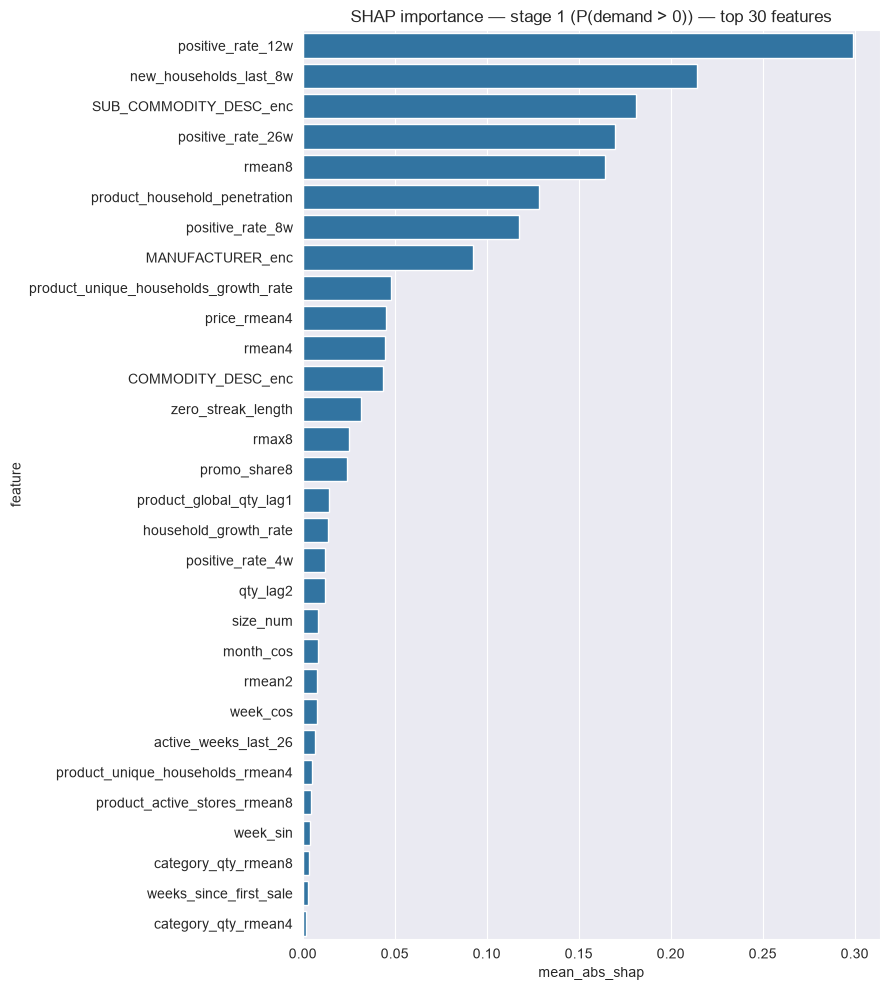


all features sorted by mean |SHAP|:
                              feature  mean_abs_shap
                    positive_rate_12w       0.298815
               new_households_last_8w       0.214448
               SUB_COMMODITY_DESC_enc       0.181079
                    positive_rate_26w       0.169729
                               rmean8       0.164251
        product_household_penetration       0.128350
                     positive_rate_8w       0.117480
                     MANUFACTURER_enc       0.092435
product_unique_households_growth_rate       0.047892
                         price_rmean4       0.045133
                               rmean4       0.044936
                   COMMODITY_DESC_enc       0.043503
                   zero_streak_length       0.031496
                                rmax8       0.024979
                         promo_share8       0.024100
              product_global_qty_lag1       0.014046
                household_growth_rate       0.013786
         

In [14]:
# 6. SHAP importance for the non-zero classifier (stage-1: P(demand > 0))
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sample = train.sample(min(5000, len(train)), random_state=SEED)
explainer = shap.TreeExplainer(stage1)
sv = np.asarray(explainer.shap_values(sample[FEATURES]))
if sv.ndim == 3:  # binary classifier returns a list [neg_class, pos_class]
    sv = sv[1]
imp = (pd.DataFrame({"feature": FEATURES, "mean_abs_shap": np.abs(sv).mean(axis=0)})
       .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))

print("top 20 features by mean |SHAP|:")
print(imp.head(20).to_string(index=False))

# all features sorted descending
fig, ax = plt.subplots(figsize=(9, 10))
sns.barplot(data=imp, x="mean_abs_shap", y="feature", color="#1f77b4", ax=ax)
ax.set_title("SHAP importance — stage 1 (P(demand > 0)) — top 30 features")
fig.tight_layout()
fig.savefig(OUT / "figures" / "shap_importance.png", dpi=140)
plt.show()

print("\nall features sorted by mean |SHAP|:")
print(imp.to_string(index=False))
imp.to_parquet(OUT / "shap_importance.parquet", index=False)

## 7. Save artifacts

Artifacts keep the interface consumed by `notebook/02_causality_analysis.ipynb` (`model.pkl` is the stage-2 alias). `test_predictions.parquet` now holds the **real held-out test predictions** (non-promoted weeks 80–101) instead of a train alias; `metrics.json` carries `train` + `test` metrics and detection diagnostics for both; `config.json` keeps the split constants for notebook 02.

In [15]:
# 7. Save artifacts
train.to_parquet(OUT / "train_predictions.parquet", index=False)
test.to_parquet(OUT / "test_predictions.parquet", index=False)  # held-out weeks 80-101, non-promoted rows
panel[["PRODUCT_ID", "STORE_ID", "WEEK_NO", "qty", "promo_week", *FEATURES]].to_parquet(OUT / "panel.parquet", index=False)
joblib.dump(stage1, OUT / "model_stage1.pkl")
joblib.dump(stage2, OUT / "model_stage2.pkl")
joblib.dump(stage2, OUT / "model.pkl")  # stage-2 alias for the causality notebook

json.dump({"features": FEATURES, "features_encoded": FEATURES,
           "cat_cols": CAT_COLS, "cat_cols_encoded": ENC_FEATURES,
           "similarity_features": [], "non_features": ["qty", "promo_week"]},
          open(OUT / "feature_list.json", "w"), indent=2)
json.dump({"train": {k.lower(): v for k, v in metrics(train["qty"], train["pred_final"]).items()},
           "test": {k.lower(): v for k, v in metrics(test["qty"], test["pred_final"]).items()},
           "detection": {"threshold": THRESHOLD,
                         "auc": float(roc_auc_score(actual_pos, new_proba)),
                         "pr_auc": float(average_precision_score(actual_pos, new_proba)),
                         "accuracy": float((pred_pos == actual_pos).mean()),
                         "non_zero": {"precision": float(p[0]), "recall": float(r[0]), "f1": float(f[0]), "support": int(sup[0])},
                         "zero": {"precision": float(p[1]), "recall": float(r[1]), "f1": float(f[1]), "support": int(sup[1])},
                         "missed_demand": missed, "false_positives": false_pos},
           "detection_test": {"threshold": THRESHOLD,
                              "auc": float(roc_auc_score(test_actual_pos, test_proba)),
                              "pr_auc": float(average_precision_score(test_actual_pos, test_proba)),
                              "accuracy": float((test_pred_pos == test_actual_pos).mean()),
                              "non_zero": {"precision": float(tp[0]), "recall": float(tr[0]), "f1": float(tf[0]), "support": int(tsup[0])},
                              "zero": {"precision": float(tp[1]), "recall": float(tr[1]), "f1": float(tf[1]), "support": int(tsup[1])},
                              "missed_demand": test_missed, "false_positives": test_false_pos}},
          open(OUT / "metrics.json", "w"), indent=2)
json.dump({"n_top_products": int(panel["PRODUCT_ID"].nunique()), "min_weeks": MIN_WEEKS,
           "train_end": TRAIN_END, "val_end": 88, "weeks": [FIRST_WEEK, LAST_WEEK - 1]},
          open(OUT / "config.json", "w"), indent=2)
json.dump({"alpha": 1.0, "lambda": 0.0, "window": 3, "method": "none (simple baseline)", "min_val_weeks": 0},
          open(OUT / "smoothing_config.json", "w"), indent=2)
train["vol_bucket"] = pd.qcut(train["pred_final"].rank(method="first"), 4, labels=False)
train.groupby("vol_bucket")["error"].agg(residual_std="std", q10=lambda s: s.quantile(0.10),
                                        q90=lambda s: s.quantile(0.90), n="size").reset_index() \
    .to_parquet(OUT / "residual_buckets.parquet", index=False)
print("artifacts saved to", OUT)

artifacts saved to /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_engine


## 8. Per-product baseline prediction quality on promoted weeks

For every **promoted** week the baseline model predicts the counterfactual demand (what would have been sold without the promotion). To see **which products the baseline predicts well**, the plot aggregates the promoted weeks per product:

- **Left:** per-product mean baseline prediction vs mean actual demand on promoted weeks (log-log; point size = number of promoted weeks). Products on the red diagonal are predicted well; products below it are under-predicted (promotion uplift not captured).
- **Right:** WAPE on promoted weeks for the 25 most-promoted products (green = low error = predicted well).

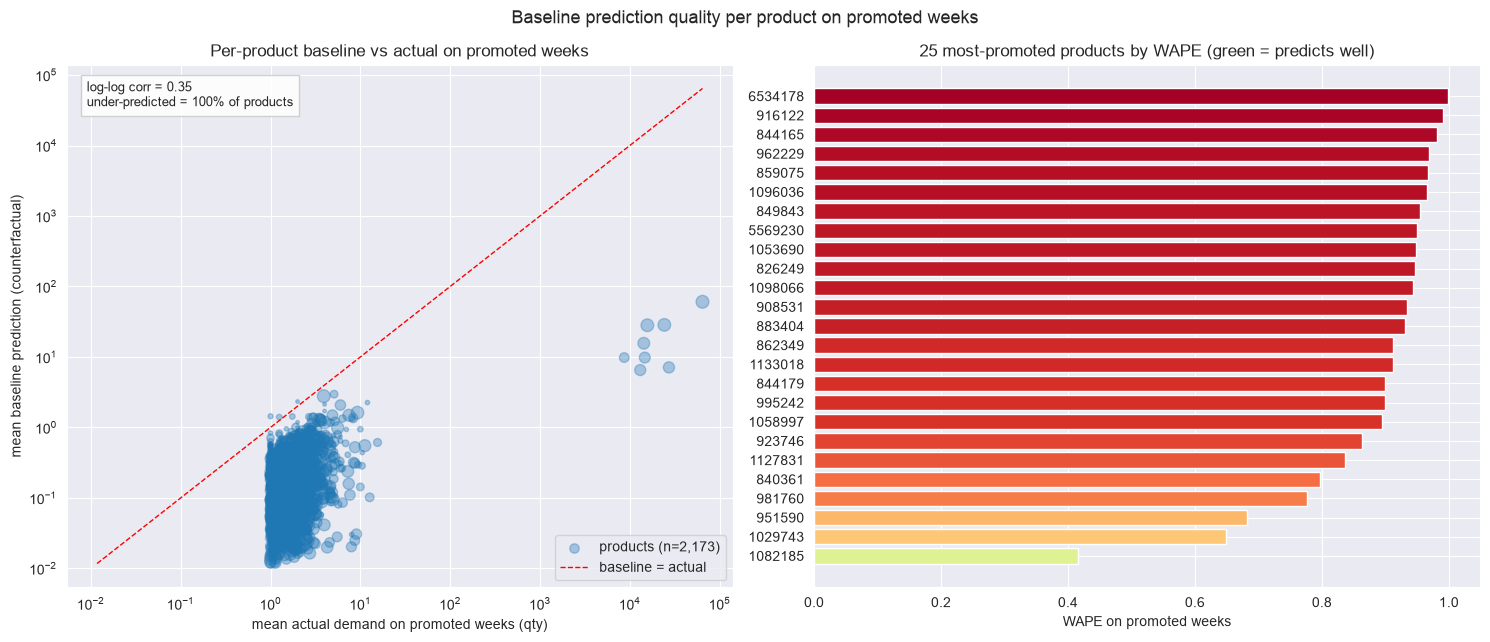

promoted weeks: 155,200 | products: 2,173 | log-log corr = 0.35 | under-predicted products = 100%


In [16]:
# 8. Per-product baseline prediction quality on promoted weeks
promo = panel.loc[panel["promo_week"] == 1].copy()
promo["pred_final"] = hurdle_predict(stage1, stage2, promo[FEATURES])
promo["abs_err"] = (promo["pred_final"] - promo["qty"]).abs()
prod = promo.groupby("PRODUCT_ID", as_index=False).agg(actual=("qty", "mean"), pred=("pred_final", "mean"),
                                                       n=("qty", "size"), abs_err=("abs_err", "sum"),
                                                       qty_sum=("qty", "sum"))
prod["wape"] = prod["abs_err"] / prod["qty_sum"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# left: per-product mean baseline pred vs mean actual on promoted weeks (log-log)
ax = axes[0]
ax.scatter(prod["actual"], prod["pred"], s=5 + 80 * prod["n"].rank(pct=True),
           alpha=0.35, color="#1f77b4", label=f"products (n={len(prod):,})")
lo = max(prod[["actual", "pred"]].min().min(), 1e-3)
hi = prod[["actual", "pred"]].max().max()
ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="baseline = actual")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean actual demand on promoted weeks (qty)")
ax.set_ylabel("mean baseline prediction (counterfactual)")
corr = np.log10(prod["actual"]).corr(np.log10(prod["pred"]))
under = float((prod["pred"] < prod["actual"]).mean())
ax.set_title("Per-product baseline vs actual on promoted weeks")
ax.text(0.03, 0.97, f"log-log corr = {corr:.2f}\nunder-predicted = {under:.0%} of products",
        transform=ax.transAxes, va="top", fontsize=9, bbox=dict(fc="white", ec="0.8", alpha=0.9))
ax.legend(loc="lower right")

# right: WAPE on promoted weeks for the 25 most-promoted products (low = predicted well)
top = prod.nlargest(25, "n").sort_values("wape")
wmax = max(top["wape"].max(), 1e-9)
ax2 = axes[1]
ax2.barh(top["PRODUCT_ID"].astype(str), top["wape"],
         color=plt.cm.RdYlGn_r(top["wape"] / wmax))
ax2.set_xlabel("WAPE on promoted weeks")
ax2.set_title("25 most-promoted products by WAPE (green = predicts well)")

fig.suptitle("Baseline prediction quality per product on promoted weeks", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "figures" / "promo_baseline_vs_actual.png", dpi=140)
plt.show()

print(f"promoted weeks: {len(promo):,} | products: {len(prod):,} | "
      f"log-log corr = {corr:.2f} | under-predicted products = {under:.0%}")

## 9. Baseline predictions vs actual sales — 5 products

Uses the **held-out** predictions saved in `test_predictions.parquet` (weeks 80–101, no retraining). Weekly actual sales and baseline predictions are aggregated across stores per product, then the 5 most-sold products in the test set are plotted as separate time series (week on the x-axis, quantity on the y-axis). One figure per product is saved under `outputs/baseline_engine/figures/`.

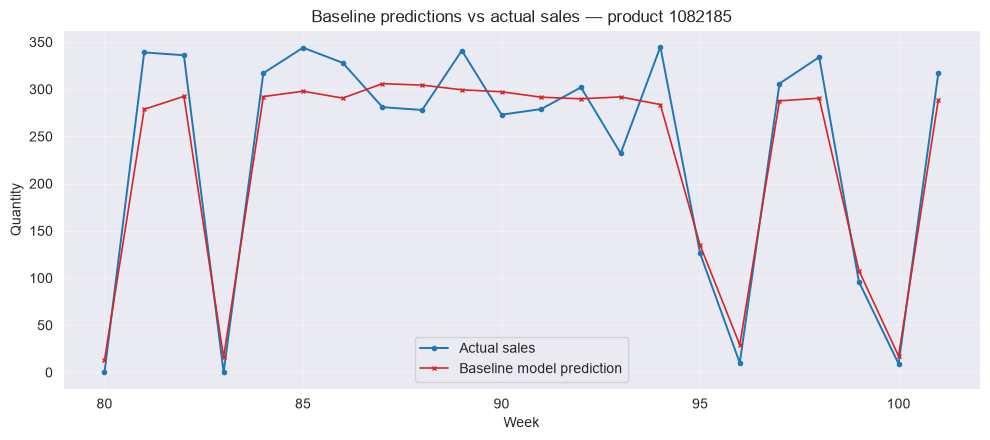

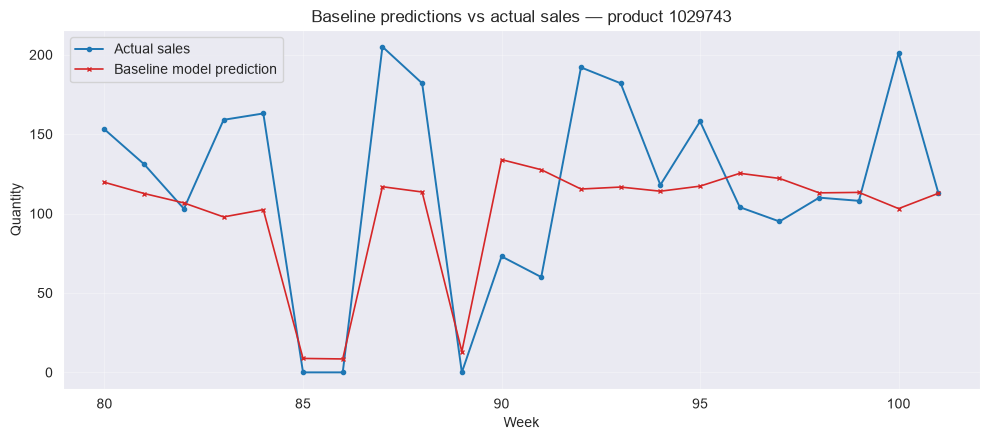

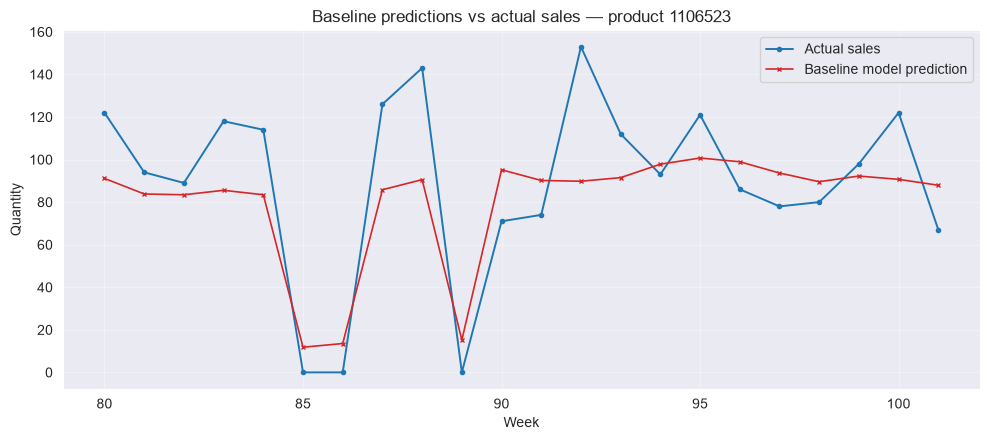

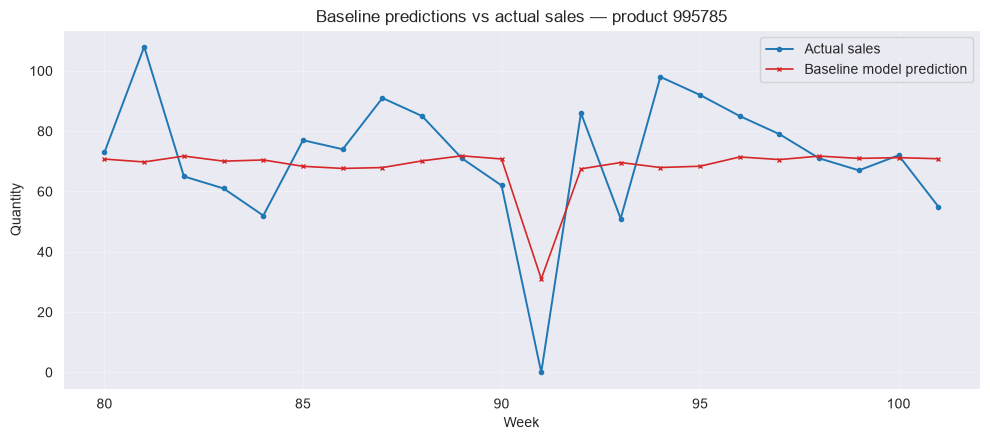

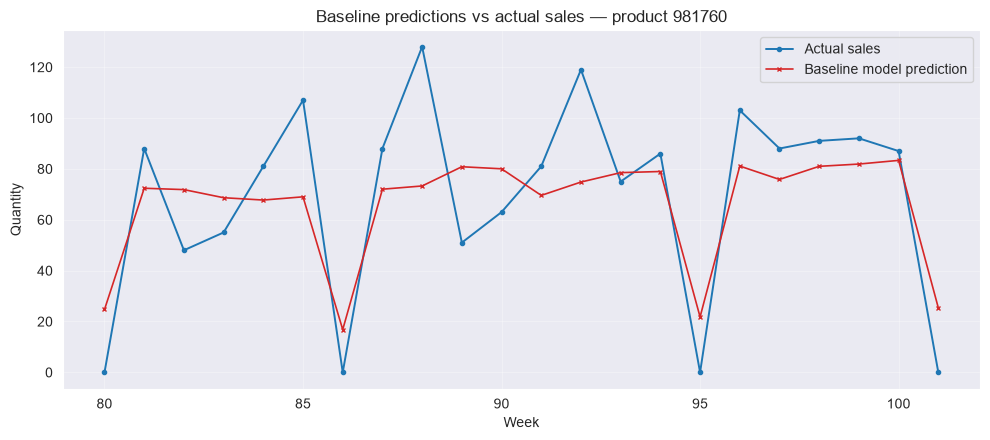

saved baseline-vs-actual plots for products [1082185, 1029743, 1106523, 995785, 981760] -> /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_engine/figures


In [17]:
# 9. Baseline predictions vs actual sales for 5 products (existing predictions, no retraining)
preds = pd.read_parquet(OUT / "test_predictions.parquet")
weekly = (preds.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
          .agg(actual=("qty", "sum"), baseline=("pred_final", "sum")))

# Select the 5 products with the most sales in the test set
top5 = weekly.groupby("PRODUCT_ID")["actual"].sum().nlargest(5).index.tolist()

for pid in top5:
    s = weekly[weekly["PRODUCT_ID"] == pid].sort_values("WEEK_NO")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(s["WEEK_NO"], s["actual"], marker="o", ms=3, lw=1.4,
            color="#1f77b4", label="Actual sales")
    ax.plot(s["WEEK_NO"], s["baseline"], marker="x", ms=3, lw=1.2,
            color="#d62728", label="Baseline model prediction")
    ax.set_xlabel("Week")
    ax.set_ylabel("Quantity")
    ax.set_title(f"Baseline predictions vs actual sales — product {pid}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT / "figures" / f"baseline_vs_actual_product_{pid}.png", dpi=140)
    plt.show()

print(f"saved baseline-vs-actual plots for products {top5} -> {OUT / 'figures'}")